<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/Homework2026/2026/HW/Wayboe/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HW 2

Shane Marshall

Feb. 24, 2026

In [8]:
import numpy as np

In [9]:
def bridge_circuit(V0, R1, R2, R3, R4, R5):
    r"""Use to find equations A @ I = b for the bridge circuit.

         B ---R4--- C (-)
         |\         |
         | R5        R2
         |  \       |
         R3   \     |
         |      \   |
    (+) A ---R1--- D


        I1: A -> B through R1
        I2: B -> C through R2
        I3: A -> D through R3
        I4: D -> C through R4
        I5: B -> D through R5

    Equations:
      (1) KCL at B:  I1 - I2 - I5 = 0
      (2) KCL at D:  I3 + I5 - I4 = 0
      (3) KVL A-B-C-A:  V0 - I1 R1 - I2 R2 = 0
      (4) KVL A-D-C-A:  V0 - I3 R3 - I4 R4 = 0
      (5) KVL B-D-C-B: -I2 R2 + I4 R4 + I5 R5 = 0

    Parameters
    ----------
    V0 : float
        Source voltage (V).
    R1, R2, R3, R4, R5 : float
        Resistances (Ohm).

    Returns
    -------
    A : numpy.ndarray
       coefficient matrix.
    b : numpy.ndarray
        vector length matrix.
    """
    A = np.array([
        [1,  -1,  0,  0, -1],     # KCL at B
        [0,   0,  1, -1,  1],     # KCL at D
        [R1, R2,  0,  0,  0],     # KVL A-B-C-A
        [0,  0,  R3, R4,  0],     # KVL A-D-C-A
        [0, -R2,  0, R4, R5],     # KVL B-D-C-B
    ], dtype=float)

    b = np.array([0, 0, V0, V0, 0], dtype=float)
    return A, b

In [10]:
def answer_circuit(A, b):
    """Solves the equations A @ I = b and return the currents.

    Parameters
    ----------
    A : numpy.ndarray
        Coefficient matrix.
    b : numpy.ndarray
        vector.

    Returns
    -------
    currents : numpy.ndarray
        Solution vector of currents.
    """
    return np.linalg.solve(A, b)

In [11]:

V0 = 10
R1 = 100
R2 = 200
R3 = 300
R4 = 600
R5 = 50

A, b = bridge_circuit(V0, R1, R2, R3, R4, R5)
currents = answer_circuit(A, b)

print("Matrix A:", A)
print("Matrix b:", b)

print("Branch currents:")
labels = ["I1 (R1)", "I2 (R2)", "I3 (R3)", "I4 (R4)", "I5 (R5)"]
for lab, val in zip(labels, currents):
    print(f"{lab:4s} = {val:.6f} A")


Matrix A: [[   1.   -1.    0.    0.   -1.]
 [   0.    0.    1.   -1.    1.]
 [ 100.  200.    0.    0.    0.]
 [   0.    0.  300.  600.    0.]
 [   0. -200.    0.  600.   50.]]
Matrix b: [ 0.  0. 10. 10.  0.]
Branch currents:
I1 (R1) = 0.033333 A
I2 (R2) = 0.033333 A
I3 (R3) = 0.011111 A
I4 (R4) = 0.011111 A
I5 (R5) = 0.000000 A


In [12]:
def power_balance(V0, R1, R2, R3, R4, R5, currents):
    """Verify conservation of energy for the bridge circuit, using the power equations:

    Power delivered by the source should equal the total resistor dissipation.

    I_source = I1 + I3.

    Parameters
    ----------
    V0 : float
        Source voltage (V).
    R1, R2, R3, R4, R5 : float
        Resistances (Ohm).
    currents : numpy.ndarray
        [I1, I2, I3, I4, I5] (A).

    Returns
    -------
     bool

      True if power balance holds within numerical tolerance.
    """
    I1, I2, I3, I4, I5 = currents

    P_source = V0 * (I1 + I3)
    P_diss = (I1**2 * R1 +
              I2**2 * R2 +
              I3**2 * R3 +
              I4**2 * R4 +
              I5**2 * R5)

    print(f"Power delivered by source:     {P_source:.6f} W")
    print(f"Power dissipated in resistors: {P_diss:.6f} W")
    return np.isclose(P_source, P_diss)

def is_bridge_balanced(R1, R2, R3, R4, tol=1e-12):
    """Return True if the bridge is balanced.

    A bridge is balanced when:
        R1/R3 == R2/R4
       which implies I5 = 0.

    Parameters
    ----------
    R1, R2, R3, R4 : float
        Bridge resistances (Ohm).
    tol : float
        Absolute tolerance passed to numpy.isclose.

    Returns
    -------
    bool
        True if balanced, else False.
    """

    if R3 == 0 or R4 == 0:
        return False
    return np.isclose(R1 / R3, R2 / R4, atol=tol, rtol=0)

In [13]:

print("Power balance:")
is_power_balanced = power_balance(V0, R1, R2, R3, R4, R5, currents)
print(f"Is power balanced: {is_power_balanced}")


print("balance check (R1/R3 == R2/R4):")
is_balanced = is_bridge_balanced(R1, R2, R3, R4)
print(f"Is bridge balanced: {is_balanced}")

Power balance:
Power delivered by source:     0.444444 W
Power dissipated in resistors: 0.444444 W
Is power balanced: True
balance check (R1/R3 == R2/R4):
Is bridge balanced: True


I used chatgpt to do this part of the homework!

1. I took me a few tries to get ChatGpt to do it in a way that made sense, the first few times, the code didn't make much sense to me or the physics

2. It took 3 tries prompting it to return something that made some sense to me.

3. This represents something like a filter, which can be used in different sensors to keep measurments more stable!


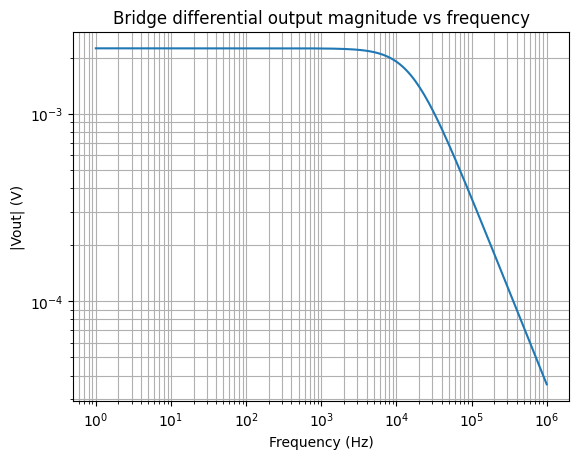


Iter 1: Vs=1V  Rg=1e+05Ω  Cf=1e-08F  fc≈159Hz
 @1kHz: |Vout|=0.00224V  Psensor=0.000207W  |Isrc|=0.000907A

Iter 2: Vs=1V  Rg=1e+05Ω  Cf=1e-08F  fc≈159Hz
 @1kHz: |Vout|=0.00224V  Psensor=0.000207W  |Isrc|=0.000907A

Iter 3: Vs=1V  Rg=1e+05Ω  Cf=1e-08F  fc≈159Hz
 @1kHz: |Vout|=0.00224V  Psensor=0.000207W  |Isrc|=0.000907A

Iter 4: Vs=1V  Rg=1e+05Ω  Cf=1e-08F  fc≈159Hz
 @1kHz: |Vout|=0.00224V  Psensor=0.000207W  |Isrc|=0.000907A

Iter 5: Vs=1V  Rg=1e+05Ω  Cf=1e-08F  fc≈159Hz
 @1kHz: |Vout|=0.00224V  Psensor=0.000207W  |Isrc|=0.000907A

Final params: {'Vs': 1.0, 'Rs': 100.0, 'R1': 1010.0, 'R2': 1000.0, 'R3': 1000.0, 'R4': 1000.0, 'Rg': 100000.0, 'Cf': 1e-08}
Final snapshot: {'Vout': np.complex128(0.0022308052333829265-0.00013911971758756927j), 'Isrc': np.complex128(-0.0009070346777860262-3.1389827975469267e-10j), 'Psensor': np.float64(0.00020668581848378746), 'fc': 159.15494309189535}
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.4/148.4 kB 8.2 MB/s eta 0:00:00


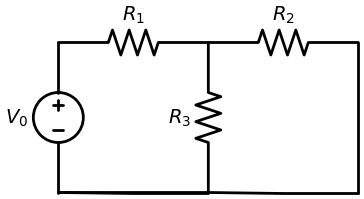

In [15]:
import numpy as np
import matplotlib.pyplot as plt

G = 0  # ground node

def mna_ac(elements, w):
    z = 1j * w

    # nodes (exclude ground) + voltage sources
    nodes = sorted({n for e in elements for n in (e["n1"], e["n2"]) if n != G})
    ni = {n:i for i,n in enumerate(nodes)}
    vsrc = [e for e in elements if e["type"] == "V"]
    N, M = len(nodes), len(vsrc)

    Y = np.zeros((N, N), complex)
    B = np.zeros((N, M), complex)
    evec = np.zeros(M, complex)

    def stamp_y(n1, n2, y):
        if n1 != G: Y[ni[n1], ni[n1]] += y
        if n2 != G: Y[ni[n2], ni[n2]] += y
        if n1 != G and n2 != G:
            i, j = ni[n1], ni[n2]
            Y[i, j] -= y; Y[j, i] -= y

    for e in elements:
        t, n1, n2, v = e["type"], e["n1"], e["n2"], e["value"]
        if t == "R": stamp_y(n1, n2, 1.0/v)
        elif t == "C": stamp_y(n1, n2, z*v)
        elif t == "L": stamp_y(n1, n2, 1.0/(z*v))
        elif t == "V": pass
        else: raise ValueError("bad type")

    for k, vs in enumerate(vsrc):
        n1, n2 = vs["n1"], vs["n2"]
        evec[k] = complex(vs["value"])
        if n1 != G: B[ni[n1], k] += 1
        if n2 != G: B[ni[n2], k] -= 1

    A = np.block([[Y, B], [B.T, np.zeros((M, M), complex)]])
    b = np.concatenate([np.zeros(N, complex), evec])
    x = np.linalg.solve(A, b)

    v = {G: 0+0j}
    for n in nodes: v[n] = x[ni[n]]
    j = x[N:]  # currents through V sources
    return v, j

def build_bridge(p):
    # nodes
    S, T, B, D = 4, 1, 2, 3
    return [
        {"type":"V","n1":S,"n2":G,"value":p["Vs"]},         # source
        {"type":"R","n1":S,"n2":T,"value":p["Rs"]},         # source resistance
        {"type":"R","n1":T,"n2":B,"value":p["R3"]},
        {"type":"R","n1":T,"n2":D,"value":p["R4"]},
        {"type":"R","n1":B,"n2":G,"value":p["R1"]},         # sensor leg
        {"type":"R","n1":D,"n2":G,"value":p["R2"]},
        {"type":"R","n1":B,"n2":D,"value":p["Rg"]},         # diff input/load
        {"type":"C","n1":B,"n2":D,"value":p["Cf"]},         # diff low-pass
    ], (B, D, S)

def snapshot(p, f):
    w = 2*np.pi*f
    elems, (B, D, S) = build_bridge(p)
    v, j = mna_ac(elems, w)
    Vout = v[B] - v[D]
    Isrc = j[0] if len(j) else 0j
    Isensor = v[B] / p["R1"]
    Psensor = (abs(Isensor)**2) * p["R1"]  # assumes Vs is RMS
    fc = 1/(2*np.pi*p["Rg"]*p["Cf"])
    return dict(Vout=Vout, Isrc=Isrc, Psensor=Psensor, fc=fc)

# ---- initial realistic-ish values (sensor bridge + differential RC) ----
p = dict(Vs=1.0, Rs=100.0, R1=1010.0, R2=1000.0, R3=1000.0, R4=1000.0, Rg=100_000.0, Cf=10e-9)

# ---- sweep + plot ----
freqs = np.logspace(0, 6, 200)
Vmag = []
for f in freqs:
    Vmag.append(abs(snapshot(p, f)["Vout"]))
Vmag = np.array(Vmag)

plt.figure()
plt.xscale("log"); plt.yscale("log")
plt.plot(freqs, Vmag)
plt.xlabel("Frequency (Hz)"); plt.ylabel("|Vout| (V)")
plt.title("Bridge differential output magnitude vs frequency")
plt.grid(True, which="both")
plt.show()

# ---- simple “does it make sense?” loop ----
P_MAX = 0.01     # 10 mW sensor self-heating guideline
V_MIN = 1e-3     # want >= 1 mV at 1 kHz to be easy to measure
f0 = 1_000

for it in range(1, 6):
    s = snapshot(p, f0)
    print(f"\nIter {it}: Vs={p['Vs']:.3g}V  Rg={p['Rg']:.3g}Ω  Cf={p['Cf']:.3g}F  fc≈{s['fc']:.3g}Hz")
    print(f" @1kHz: |Vout|={abs(s['Vout']):.3g}V  Psensor={s['Psensor']:.3g}W  |Isrc|={abs(s['Isrc']):.3g}A")


    # auto-fixes (minimal heuristics)
    if s["Psensor"] > P_MAX:         # too much heating → reduce excitation & raise resistances
        p["Vs"] *= 0.6
        for k in ("R1","R2","R3","R4"): p[k] *= 2
    if abs(s["Vout"]) < V_MIN:       # too small output → lighten load/filter and bump Vs a bit
        p["Vs"] *= 1.3
        p["Rg"] *= 2
        p["Cf"] *= 0.5

print("\nFinal params:", p)
print("Final snapshot:", snapshot(p, f0))

!pip install schemdraw
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    d += elm.SourceV().up().label('$V_0$')
    d += elm.Resistor().right().label('$R_1$')
    d.push()
    d += elm.Resistor().down().label('$R_3$')
    d += elm.Line().left()
    d.pop()
    d += elm.Resistor().right().label('$R_2$')
    d += elm.Line().down()
    d += elm.Line().left()
    d += elm.Line().left()